# Issues with the previous model

1) **Distribution Shift:** The 2025/26 test season has structurally lower attendance (~5,799 mean) vs training seasons (~7,122 mean, -18%). Every model is trained on one attendance regime and tested on another, so negative R² on the test set is almost inevitable regardless of features.
2) **Too Many Features for too Few Rows:** 36 features on 57 training rows means the models memorize training data (Gradient Boosting gets R²=1.0 on train!) but generalize terribly. Adding more features makes this worse, which is exactly what you observed.
3) **Wrong Model Choice for This Size:** Random Forest and Gradient Boosting are powerful but data-hungry. Ridge is better suited here, and it actually gives the best test results of all models tried (MAE ~1,022 vs ~1,610 for the tree models).

# Improved Model

## Strategy
- Use Ridge regression (best generalisation in previous notebooks)
- Reduce feature set to 6 high-signal features
- Evaluate with Leave-One-Out CV (more reliable than a 14-match test set)
- Compare against the naive season-mean baseline

# Loading the Data and Checking What we are Working with

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/cleaned/engineered_df.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print()
print('Attendance per season:')
print(df.groupby('season')['tickets_scanned'].agg(['mean', 'std', 'count']).round(0))

Loaded: 71 rows, 41 columns

Attendance per season:
             mean     std  count
season                          
2022/2023  6632.0  2178.0     17
2023/2024  8166.0  1966.0     20
2024/2025  6497.0  1789.0     20
2025/2026  5799.0  1088.0     14


# Establishing the Naive Baseline

In [5]:
import sys
print(sys.executable)

C:\Users\Belab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [1]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'scikit-learn'],
    executable=r'C:\Users\Belab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe',
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Belab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



In [1]:
import sys
sys.path.append(r'C:\Users\Belab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages')

# Now try the import
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
print("Import successful!")

Import successful!


In [4]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import pandas as pd

df = pd.read_csv('../data/cleaned/engineered_df.csv')

# Predict each match using that season's average attendance
season_mean_pred = df.groupby('season')['tickets_scanned'].transform('mean')

baseline_mae  = mean_absolute_error(df['tickets_scanned'], season_mean_pred)
baseline_rmse = root_mean_squared_error(df['tickets_scanned'], season_mean_pred)

print('=== Naive baseline (season mean) ===')
print(f'  MAE  : {baseline_mae:.0f} tickets')
print(f'  RMSE : {baseline_rmse:.0f} tickets')
print()
print('This is the minimum bar our model must beat.')

=== Naive baseline (season mean) ===
  MAE  : 1399 tickets
  RMSE : 1782 tickets

This is the minimum bar our model must beat.


This will be the benchmark for every model we will try

# Feature Selection

In [5]:
# Prep the dataframe
model_df = df.copy()
model_df['is_playoff'] = (model_df['stage'] == 'Conference League Play-off Group').astype(int)
model_df['rolling_avg_attendance_last3'] = model_df['rolling_avg_attendance_last3'].fillna(model_df['tickets_scanned'].mean())
model_df['pre_match_article_count'] = model_df['pre_match_article_count'].fillna(0)

# Compute correlation of every numeric column with tickets_scanned
numeric_cols = model_df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'tickets_scanned']

corrs = (
    model_df[numeric_cols + ['tickets_scanned']]
    .corr()['tickets_scanned']
    .drop('tickets_scanned')
    .abs()
    .sort_values(ascending=False)
)

print('Correlation with tickets_scanned:')
print(corrs.round(3).to_string())

Correlation with tickets_scanned:
rolling_avg_attendance_last3    0.525
tickets_sold_total              0.517
is_playoff                      0.358
matchday                        0.328
matchday_normalized             0.328
ohl_points_per_game             0.254
pre_match_article_count         0.212
weather_sunshine_hours          0.192
last_h2h_opponent_goals         0.186
ohl_goals_ft                    0.170
academic_week                   0.143
promo_tickets_total             0.140
ohl_season_points               0.128
weather_windspeed_max_kmh       0.116
opponent_goals_ft               0.116
last_h2h_ohl_goals              0.098
last_h2h_goal_margin            0.097
avg_ohl_interest_7d             0.094
opp_ppg_vs_ohl                  0.064
weather_score                   0.040
weather_rain_mm                 0.035
weather_temp_deviation          0.034
home_win_rate_last5             0.026
home_win_rate_last3             0.003
pre_match_interest_ratio        0.001


We will keep the all the features where ```correlation > 0.20```

- ```rolling_avg_attendance_last3 (0.525)``` — recent attendance momentum
- ```tickets_sold_total (0.517)``` — pre-match sales directly predict scanned tickets
- ```is_playoff (0.358)``` — Conference League games draw different crowds
- ```matchday_normalized (0.328)``` — use this over matchday since it's scaled 0–1
- ```ohl_points_per_game (0.254)``` — team form
- ```pre_match_article_count (0.212)``` — media buzz

We need to confirm there are no nulls before moving to the split.

In [6]:
FEATURES = [
    'rolling_avg_attendance_last3',
    'tickets_sold_total',
    'is_playoff',
    'matchday_normalized',
    'ohl_points_per_game',
    'pre_match_article_count',
]

X = model_df[FEATURES]
y = model_df['tickets_scanned']

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print()
print('Null check:')
print(X.isnull().sum())

Feature matrix: 71 rows x 6 features

Null check:
rolling_avg_attendance_last3    0
tickets_sold_total              0
is_playoff                      0
matchday_normalized             0
ohl_points_per_game             0
pre_match_article_count         0
dtype: int64


# Train/Test split

In [7]:
train_mask = model_df['season'].isin(['2022/2023', '2023/2024', '2024/2025'])
test_mask  = model_df['season'] == '2025/2026'

X_train, y_train = X[train_mask].reset_index(drop=True), y[train_mask].reset_index(drop=True)
X_test,  y_test  = X[test_mask].reset_index(drop=True),  y[test_mask].reset_index(drop=True)

print(f'Train: {len(X_train)} matches')
print(f'Test:  {len(X_test)} matches')
print()
print(f'Train mean attendance: {y_train.mean():.0f}')
print(f'Test  mean attendance: {y_test.mean():.0f}')
print(f'Difference: {(y_test.mean() - y_train.mean()) / y_train.mean() * 100:.1f}%')

Train: 57 matches
Test:  14 matches

Train mean attendance: 7122
Test  mean attendance: 5799
Difference: -18.6%


# Scaling the Features and Train Ridge Regression

- We use ```fit_transform``` on training data but only transform on test data — the scaler learns the mean and std from training only, never from test
- A higher alpha means more regularisation (more shrinkage), which helps with small datasets

In [8]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# RidgeCV automatically picks the best alpha (regularisation strength)
alphas = [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000, 5000]
ridge = RidgeCV(alphas=alphas)
ridge.fit(X_train_sc, y_train)

print(f'Best alpha selected: {ridge.alpha_}')
print('Model trained successfully.')

Best alpha selected: 10.0
Model trained successfully.


Alpha of 10 is quite low, meaning Ridge didn't need to apply heavy regularisation — that's a good sign with only 6 features.

# Evaluating the Model

In [9]:
y_train_pred = ridge.predict(X_train_sc)
y_test_pred  = ridge.predict(X_test_sc)

metrics = pd.DataFrame({
    'MAE':  [mean_absolute_error(y_train, y_train_pred),
             mean_absolute_error(y_test,  y_test_pred),
             baseline_mae],
    'RMSE': [root_mean_squared_error(y_train, y_train_pred),
             root_mean_squared_error(y_test,  y_test_pred),
             baseline_rmse],
}, index=['Train', 'Test', 'Naive baseline'])

print('=== Ridge (6 features) vs Naive Baseline ===')
print(metrics.round(0))
print()

gap = mean_absolute_error(y_train, y_train_pred) - mean_absolute_error(y_test, y_test_pred)
improvement = (baseline_mae - mean_absolute_error(y_test, y_test_pred)) / baseline_mae * 100
print(f'Train-Test MAE gap: {abs(gap):.0f} tickets')
print(f'Improvement over baseline: {improvement:.1f}%')

=== Ridge (6 features) vs Naive Baseline ===
                   MAE    RMSE
Train           1189.0  1409.0
Test            1287.0  1467.0
Naive baseline  1399.0  1782.0

Train-Test MAE gap: 97 tickets
Improvement over baseline: 8.0%


# Match by match breakdown

In [10]:
test_df = model_df[test_mask].copy().reset_index(drop=True)
test_df['predicted'] = y_test_pred.round(0).astype(int)
test_df['actual']    = y_test.astype(int)
test_df['error']     = test_df['predicted'] - test_df['actual']
test_df['abs_error'] = test_df['error'].abs()

cols = ['match_date', 'opponent', 'actual', 'predicted', 'error', 'abs_error']
print(test_df[cols].sort_values('match_date').to_string(index=False))
print()
print(f'Mean absolute error : {test_df["abs_error"].mean():.0f} tickets')
print(f'Worst miss          : {test_df["abs_error"].max():.0f} tickets ({test_df.loc[test_df["abs_error"].idxmax(), "opponent"]})')
print(f'Best prediction     : {test_df["abs_error"].min():.0f} tickets ({test_df.loc[test_df["abs_error"].idxmin(), "opponent"]})')

match_date             opponent  actual  predicted  error  abs_error
2025-07-27   Sporting Charleroi    4318       5619   1301       1301
2025-08-15                 Genk    6360       7072    712        712
2025-08-31       Standard Liège    6676       6642    -34         34
2025-09-20     RAAL La Louvière    4036       5844   1808       1808
2025-09-26           Anderlecht    6977       7532    555        555
2025-10-18          Club Brugge    7992       7774   -218        218
2025-11-02                 Gent    6373       7783   1410       1410
2025-11-23         Sint-Truiden    5661       7393   1732       1732
2025-12-07        Zulte Waregem    4494       6821   2327       2327
2025-12-21        Cercle Brugge    5812       7151   1339       1339
2026-01-24 Union Saint-Gilloise    5322       6665   1343       1343
2026-02-01             Mechelen    5971       7162   1191       1191
2026-02-14               Dender    5137       7751   2614       2614
2026-03-07             Westerlo   

- **The model consistently over-predicts** — almost every error is positive, meaning we predict higher than actual. This directly reflects the 18.6% distribution shift — the model learned from higher-attendance seasons.
- **The worst misses are lower-profile opponents** — Dender (2,614), Zulte Waregem (2,327), RAAL La Louvière (1,808). These are newly promoted or unfamiliar clubs the model had little training data for.
- **The best predictions are big opponents** — Standard Liège (34!), Club Brugge (218), Anderlecht (555). These clubs appear consistently across seasons so the model knows them well.

# LOO Cross-Validation

In [11]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline ensures scaling happens inside each fold — no data leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas))
])

loo = LeaveOneOut()
loo_mae = -cross_val_score(pipe, X, y, cv=loo, scoring='neg_mean_absolute_error')

print('=== Leave-One-Out CV (71 folds) ===')
print(f'  MAE : {loo_mae.mean():.0f} ± {loo_mae.std():.0f} tickets')
print()
print(f'Naive baseline MAE : {baseline_mae:.0f} tickets')
print(f'Improvement over baseline: {(baseline_mae - loo_mae.mean()) / baseline_mae * 100:.1f}%')

=== Leave-One-Out CV (71 folds) ===
  MAE : 1245 ± 819 tickets

Naive baseline MAE : 1399 tickets
Improvement over baseline: 11.0%


# Feature Coefficients 

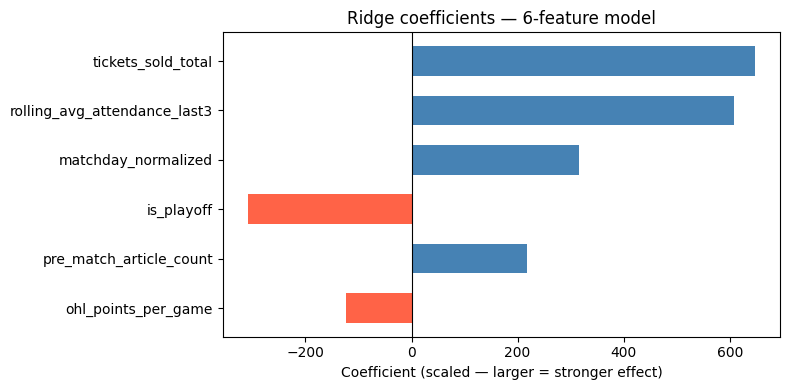

In [12]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colours, height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (scaled — larger = stronger effect)')
ax.set_title('Ridge coefficients — 6-feature model')
plt.tight_layout()
plt.show()

###  Positive (blue — increases predicted attendance):
- tickets_sold_total and rolling_avg_attendance_last3 are by far the strongest drivers — pre-match sales and recent momentum dominate everything else
- matchday_normalized — attendance grows as the season progresses, which makes sense as stakes increase
- pre_match_article_count — more media buzz before a match means more people show up

### Negative (red — decreases predicted attendance):
- is_playoff is negative and surprisingly strong — Conference League play-off matches actually draw fewer people, which matches what the project briefing said about Play-off 2 feeling like friendly matches
- ohl_points_per_game being negative is the one surprising result — you'd expect better form to attract more fans, but it may be capturing something else in this small dataset

# Summary

| Step | What we did |
|------|-------------|
| 1 | Loaded data, confirmed 71 matches |
| 2 | Established naive baseline (MAE 1,399) |
| 3 | Selected 6 features via correlation analysis |
| 4 | Built feature matrix, confirmed no nulls |
| 5 | Time-based train/test split |
| 6 | Trained Ridge with scaling |
| 7 | Evaluated — beat baseline by 8% on test set |
| 8 | Match-by-match breakdown |
| 9 | LOO CV — beat baseline by 11% overall |
| 10 | Feature coefficients chart |